In [25]:
# Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [26]:
df_india = df[df['job_country'] == 'India'].copy()

In [27]:
df_india['job_posted_month'] = df_india.job_posted_date.dt.strftime('%b')

In [28]:
df_india_pivot = df_india.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

In [29]:
df_india_pivot.reset_index(inplace=True)

In [30]:
df_india_pivot['job_month_no'] = pd.to_datetime(df_india_pivot['job_posted_month'],format='%b').dt.month
df_india_pivot.sort_values('job_month_no', inplace=True)
df_india_pivot.set_index('job_posted_month',inplace=True)
df_india_pivot.drop(columns='job_month_no', inplace=True)

In [31]:
top_3 = df_india.value_counts('job_title_short').head(3).index.to_list()

In [32]:
df_india_pivot = df_india_pivot[top_3]
df_india_pivot

job_title_short,Data Engineer,Data Scientist,Data Analyst
job_posted_month,,,
Jan,2132,1444,628
Feb,1631,932,433
Mar,1591,1005,422
Apr,1566,946,418
May,1384,837,278
Jun,1632,1129,367
Jul,1528,1123,457
Aug,1407,1157,618
Sep,1508,984,630


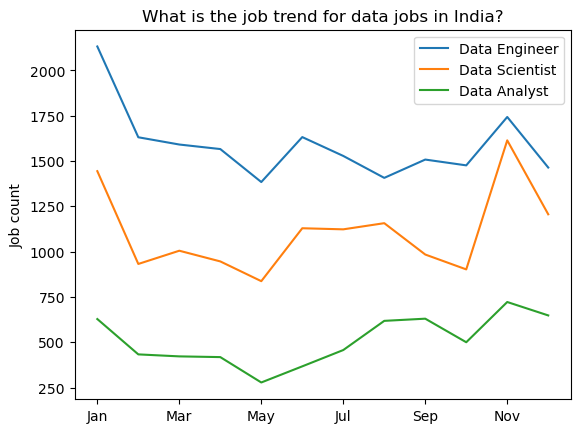

In [34]:
df_india_pivot.plot(kind='line')
plt.xlabel('')
plt.ylabel('Job count')
plt.title('What is the job trend for data jobs in India?')
plt.legend(title='')
plt.show()